## Project objective
#### To analyze walmart's smartphone marketplace to understand seller participation, pricing behavior, customer sentiment, recommendation trends, and category performance
##### Product Analyzed 92 , Reviews Scraped 1.3k+ 
#### Following KPI's used to quantify the progress 
##### 1. Average Product Rating
##### 2. Recommendation Rate (%)
##### 3. Net Promoter Score (NPS)
##### 4. Share of Voice (SoV)
##### 5. Seller Catalog Reach (%)
##### 6. Average Product Price
##### 7. Price–Rating Correlation
##### 8. Sentiment Gap Score
##### 9. Review Volume
##### 10. Review Text Length
#### Conclusion 
##### 1. Marketplace is highly concentrated with Walmart.com accounting for the majority of product catalog (~54.3%) , while third-party sellers contribute to marketplace diversity , their participation remains relatively limited compared to walmart owned inventory
##### 2. Walmart specifically competes on accessibility , avg pricing 154.38 USD , and catalog reach of ~54.3%), rather than premium pricing (where average prices reach up to $939.48 while catalog reach remains limited to ~1.1%)
##### 3. Product unit distribution across different segment are in (budget:461 , mid-tier:432 , premium:420) 
##### 4. All Cell Phones (prod_category) experienced the steepest sentiment decline of (-2.7 rating points), indicating a significant deterioration in recent customer satisfaction exp compared to avg historical performance.
##### 5. Prepaid Android Phones captures strong word of mouth recommendation with 186 positive recommendation.
##### 6. All Samsung Galaxy Unlocked Phones achieved the highest NPS of 40.3 , where NPS means Net promoter score , showing stronger customer loyalty and fanbase.
##### 7. All Samsung Galaxy Unlocked Phones occupy the strongest strategic position with customer advocacy of (NPS 40.3) and strong market visibility (~18% SoV , share of voice)
##### 8. Non-recommended reviews are significantly longer near abt 47 words than recommended reviews of 37 word count, suggesting dissatisfied customers provide more detailed feedback and pain points.

#### Recommendation 

##### 1. Increase onboarding and visibility of mid-sized sellers to reduce dependence on Walmart's 54.3% catalog dominance to improve seller's diversification and embrace competitive price.
##### 2. Expand product offerings in the mid-tier smartphone segment ($300–700) to capture higher-margin customers while maintaining affordability.
##### 3. Conduct RCA on product categories exhibiting the largest sentiment decline to proactively understand and address the emerging customer pain points.
##### 4. Prioritize inventory allocation and promotional investments toward highly recommended product categories to maximize customer advocacy and conversion potential.
##### 5. Benchmark the product, pricing, and customer experience strategies of high-NPS categories and replicate best practices across lower-performing segments.
##### 6. Analyze recurring themes within longer non-recommended reviews to identify factors influencing customer recommendation behavior.


#### Data cleaning process

In [78]:
import pandas as pd

In [79]:
df_product=pd.read_csv(r"D:\webscraping\product_info_walmart.csv")

In [80]:
df_product.head(4)

,SKU_id,product_name,product_category,seller_name,seller_id,price,availability_status,average_rating,number_of_reviews,product_link
0,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...
1,16385702047,"AT&T Propel 3 5G, 64GB, Midnight Blue - Prepai...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,34.88,IN_STOCK,4.2,153,/ip/ATT-Propel-3-5G/16385702047
2,19209163478,Samsung Galaxy S26 Ultra 256GB Smartphone Unlo...,Cell Phones,Gotham Cells,4774B63055DE423D8BB399DD0AD29593,1049.99,IN_STOCK,4.8,12296,/ip/M3-256GB-Cobalt-Violet/19209163478
3,17607251346,"Walmart Family Mobile Samsung Galaxy A17, 5G, ...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,119.00,IN_STOCK,4.6,18,/ip/FM-SAMSUNG-S176V-A17-5G-PIB-HANDSET-WALMAR...


In [4]:
df_review=pd.read_csv(r"D:\webscraping\review_info_walmart.csv")

In [5]:
df_review.head(3)

,SKU_id,item_name,product_category,review_rating,review_title,review_text,review_date,recommended,positive_feedback,negative_feedback,reviewer_name,review_language,fulfilled_by,review_source
0,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,2.0,Verizon phone switch,The phone was a verizon phone and was supposed...,12/24/2025,False,0.0,0.0,Catherine,English,Walmart,bazaarvoice
1,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,1.0,NaN,it wont let me set the phone up,12-08-2025,False,0.0,0.0,Alison,English,Walmart,bazaarvoice
2,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,5.0,it was very easy to setup this phone,i like that the phone is quick and fast by the...,12-10-2025,True,0.0,0.0,Ben,English,Walmart,bazaarvoice


In [6]:
df_product.head()

,SKU_id,product_name,product_category,seller_name,seller_id,price,availability_status,average_rating,number_of_reviews,product_link
0,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...
1,16385702047,"AT&T Propel 3 5G, 64GB, Midnight Blue - Prepai...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,34.88,IN_STOCK,4.2,153,/ip/ATT-Propel-3-5G/16385702047
2,19209163478,Samsung Galaxy S26 Ultra 256GB Smartphone Unlo...,Cell Phones,Gotham Cells,4774B63055DE423D8BB399DD0AD29593,1049.99,IN_STOCK,4.8,12296,/ip/M3-256GB-Cobalt-Violet/19209163478
3,17607251346,"Walmart Family Mobile Samsung Galaxy A17, 5G, ...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,119.00,IN_STOCK,4.6,18,/ip/FM-SAMSUNG-S176V-A17-5G-PIB-HANDSET-WALMAR...
4,18263516985,"Cricket Wireless Samsung Galaxy A17 128GB , 4G...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,79.00,IN_STOCK,4.5,114,/ip/Cricket-Wireless-Samsung-Galaxy-A17-128GB-...


In [7]:
df_product.shape

(118, 10)

In [8]:
df_product.dtypes

SKU_id                   int64
product_name            object
product_category        object
seller_name             object
seller_id               object
price                  float64
availability_status     object
average_rating         float64
number_of_reviews        int64
product_link            object
dtype: object

In [9]:
df_product.shape

(118, 10)

In [10]:
df_review.shape

(1326, 14)

In [11]:
df_review.dropna(subset=['product_category'],inplace=True)

In [12]:
df_review.isna().sum()

SKU_id                 0
item_name              0
product_category       0
review_rating          0
review_title         440
review_text            4
review_date            0
recommended          566
positive_feedback      0
negative_feedback      0
reviewer_name         69
review_language        0
fulfilled_by         674
review_source          0
dtype: int64

In [13]:
df_review['reviewer_name'] = df_review['reviewer_name'].fillna('Unknown')
df_review['review_title'] = df_review['review_title'].fillna('No title')
df_review['review_text'] = df_review['review_text'].fillna('No Reviews..')

In [14]:
df_review.isna().sum()

SKU_id                 0
item_name              0
product_category       0
review_rating          0
review_title           0
review_text            0
review_date            0
recommended          566
positive_feedback      0
negative_feedback      0
reviewer_name          0
review_language        0
fulfilled_by         674
review_source          0
dtype: int64

In [15]:
df_review['recommended']=df_review['recommended'].fillna('No recommendation')

In [16]:
df_review['fulfilled_by']=df_review['fulfilled_by'].fillna('unknown')

In [17]:
df_review.isna().sum()

SKU_id               0
item_name            0
product_category     0
review_rating        0
review_title         0
review_text          0
review_date          0
recommended          0
positive_feedback    0
negative_feedback    0
reviewer_name        0
review_language      0
fulfilled_by         0
review_source        0
dtype: int64

In [18]:
df_product.isna().sum()

SKU_id                 0
product_name           0
product_category       0
seller_name            0
seller_id              0
price                  0
availability_status    0
average_rating         3
number_of_reviews      0
product_link           0
dtype: int64

In [19]:
df_product['average_rating']=df_product['average_rating'].fillna(df_product['average_rating'].median())

In [20]:
df_product.isna().sum()

SKU_id                 0
product_name           0
product_category       0
seller_name            0
seller_id              0
price                  0
availability_status    0
average_rating         0
number_of_reviews      0
product_link           0
dtype: int64

In [21]:
df_review.isna().sum()

SKU_id               0
item_name            0
product_category     0
review_rating        0
review_title         0
review_text          0
review_date          0
recommended          0
positive_feedback    0
negative_feedback    0
reviewer_name        0
review_language      0
fulfilled_by         0
review_source        0
dtype: int64

In [22]:
df_review=df_review.rename(columns={'product_category':'review_category'})

In [23]:
df_review.isna().sum()

SKU_id               0
item_name            0
review_category      0
review_rating        0
review_title         0
review_text          0
review_date          0
recommended          0
positive_feedback    0
negative_feedback    0
reviewer_name        0
review_language      0
fulfilled_by         0
review_source        0
dtype: int64

In [24]:
df_review.dtypes

SKU_id                 int64
item_name             object
review_category       object
review_rating        float64
review_title          object
review_text           object
review_date           object
recommended           object
positive_feedback    float64
negative_feedback    float64
reviewer_name         object
review_language       object
fulfilled_by          object
review_source         object
dtype: object

In [25]:
df_product.dtypes

SKU_id                   int64
product_name            object
product_category        object
seller_name             object
seller_id               object
price                  float64
availability_status     object
average_rating         float64
number_of_reviews        int64
product_link            object
dtype: object

In [26]:
df_product=df_product.rename(columns={'price':'price($)'})

In [27]:
df_product.dtypes

SKU_id                   int64
product_name            object
product_category        object
seller_name             object
seller_id               object
price($)               float64
availability_status     object
average_rating         float64
number_of_reviews        int64
product_link            object
dtype: object

In [29]:
df_review['SKU_id'].nunique()

92

In [31]:
df_review.dtypes

SKU_id                 int64
item_name             object
review_category       object
review_rating        float64
review_title          object
review_text           object
review_date           object
recommended           object
positive_feedback    float64
negative_feedback    float64
reviewer_name         object
review_language       object
fulfilled_by          object
review_source         object
dtype: object

In [32]:
df_review

,SKU_id,item_name,review_category,review_rating,review_title,review_text,review_date,recommended,positive_feedback,negative_feedback,reviewer_name,review_language,fulfilled_by,review_source
0,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,2.0,Verizon phone switch,The phone was a verizon phone and was supposed...,12/24/2025,False,0.0,0.0,Catherine,English,Walmart,bazaarvoice
1,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,1.0,No title,it wont let me set the phone up,12-08-2025,False,0.0,0.0,Alison,English,Walmart,bazaarvoice
2,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,5.0,it was very easy to setup this phone,i like that the phone is quick and fast by the...,12-10-2025,True,0.0,0.0,Ben,English,Walmart,bazaarvoice
3,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,5.0,fun phone,I absolutely like this phone it takes really g...,2/25/2026,True,0.0,0.0,Kayla,English,Walmart,bazaarvoice
4,16845857094,"Straight Talk Alcatel TCL K33, 5G, 64GB, Gray ...",5G Prepaid Phones,1.0,No title,Instacart shopper did mot have it scanned unab...,05-04-2026,No recommendation,0.0,0.0,anonymous,English,Walmart,bazaarvoice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1320,916649084,Restored Apple iPhone 8 - Carrier Unlocked - 6...,iPhone,3.0,Phone had slight problems,The camera doesn't work it's shakey and I can'...,2/26/2026,True,0.0,0.0,Natalie G,English,unknown,Wholescale
1321,916649084,Restored Apple iPhone 8 - Carrier Unlocked - 6...,iPhone,5.0,Great so far,"I have only had the iPhone XR for a week, but ...",02-12-2026,True,0.0,0.0,Sharee B,English,unknown,Wholescale
1322,916649084,Restored Apple iPhone 8 - Carrier Unlocked - 6...,iPhone,1.0,An expensive defective item,"Ive only had this phone for 3 weeks, and it sh...",1/15/2022,False,1.0,0.0,Stace,English,unknown,bazaarvoice
1323,916649084,Restored Apple iPhone 8 - Carrier Unlocked - 6...,iPhone,1.0,Very Dissatisfied,Use a phone for a refurbished phone quality is...,7/22/2021,No recommendation,1.0,0.0,mystique,English,unknown,bazaarvoice


In [33]:
df_final_merged=pd.merge(df_product,df_review ,on='SKU_id' , how='inner')

In [34]:
df_final_merged.shape

(1313, 23)

In [35]:
df_final_merged.dtypes

SKU_id                   int64
product_name            object
product_category        object
seller_name             object
seller_id               object
price($)               float64
availability_status     object
average_rating         float64
number_of_reviews        int64
product_link            object
item_name               object
review_category         object
review_rating          float64
review_title            object
review_text             object
review_date             object
recommended             object
positive_feedback      float64
negative_feedback      float64
reviewer_name           object
review_language         object
fulfilled_by            object
review_source           object
dtype: object

In [36]:
df_final_merged.to_csv(r"D:\webscraping\final_analytics_file.csv",index=False)

In [37]:
# Price distribution between budget , midrange and premium range
df_final_merged['price_tier'] = pd.qcut(df_final_merged['price($)'], q=3, labels=['Budget', 'Mid-Range', 'Premium'])

# share's
seller_share = df_final_merged.groupby('seller_name')['SKU_id'].nunique()

In [38]:
df_final_merged.nunique()

SKU_id                   92
product_name             92
product_category          1
seller_name              27
seller_id                27
price($)                 63
availability_status       1
average_rating           18
number_of_reviews        87
product_link             92
item_name                97
review_category          14
review_rating             5
review_title            785
review_text            1298
review_date             613
recommended               3
positive_feedback        18
negative_feedback         8
reviewer_name           991
review_language           1
fulfilled_by              3
review_source             3
price_tier                3
dtype: int64

## EDA 

#### Based on 92 unique sku_id and 1.3k+ reviews collected through scraping from walmart site 

In [71]:
min_review_threshold = 20
scraped_counts = df_final_merged.groupby('review_category')['review_text'].transform('count')
robust_df = df_final_merged[scraped_counts >= min_review_threshold]
filtered_df = robust_df.copy()
rec_percentages = pd.crosstab(filtered_df['review_category'], filtered_df['recommended'], normalize='index') * 100
print("\t\t\tRecommendation value distribution across various review_category")
print(rec_percentages)

			Recommendation value distribution across various review_category
recommended                             False       True  No recommendation
review_category                                                            
5G Prepaid Phones                   20.625000  53.750000          25.625000
5G Unlocked Phones                  16.296296  31.111111          52.592593
All Samsung Galaxy Prepaid Phones   16.176471  42.647059          41.176471
All Samsung Galaxy Unlocked Phones   6.995885  47.325103          45.679012
Prepaid Android phones              24.390244  37.804878          37.804878
Prepaid iPhones                      0.000000  31.250000          68.750000
Straight Talk Phones & Plans        14.000000  19.000000          67.000000
Straight Talk iPhone                15.000000  32.500000          52.500000
iPhone                              20.000000  35.000000          45.000000


#### Plot to show the seller's catalog reach or penetration 

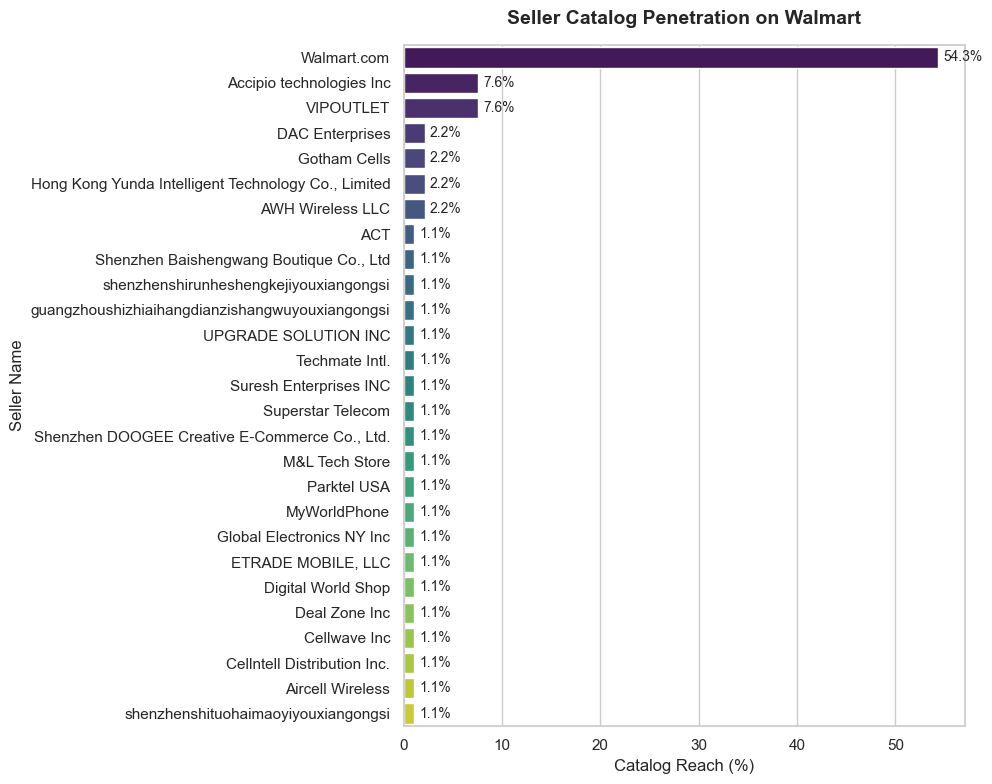

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

seller_reach = (df_final_merged.groupby('seller_name')['SKU_id'].nunique() / 92) * 100
seller_reach_sorted = seller_reach.sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='SKU_id', y='seller_name', data=seller_reach_sorted, hue='seller_name', palette='viridis')

plt.title('Seller Catalog Penetration on Walmart', fontsize=14, pad=15, weight='bold')
plt.xlabel('Catalog Reach (%)', fontsize=12)
plt.ylabel('Seller Name', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    if width > 0: 
        ax.text( width + 0.5,  p.get_y() + p.get_height() / 2,   f'{width:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [41]:
print(seller_reach_sorted)

                                          seller_name     SKU_id
0                                         Walmart.com  54.347826
1                            Accipio technologies Inc   7.608696
2                                           VIPOUTLET   7.608696
3                                     DAC Enterprises   2.173913
4                                        Gotham Cells   2.173913
5   Hong Kong Yunda Intelligent Technology Co., Li...   2.173913
6                                    AWH Wireless LLC   2.173913
7                                                 ACT   1.086957
8             Shenzhen Baishengwang Boutique Co., Ltd   1.086957
9              shenzhenshirunheshengkejiyouxiangongsi   1.086957
10    guangzhoushizhiaihangdianzishangwuyouxiangongsi   1.086957
11                               UPGRADE SOLUTION INC   1.086957
12                                     Techmate Intl.   1.086957
13                             Suresh Enterprises INC   1.086957
14                       

In [42]:
seller_price= df_final_merged.groupby('seller_name')['price($)'].mean()
print(seller_price)

seller_name
ACT                                                    288.880000
AWH Wireless LLC                                       148.760588
Accipio technologies Inc                               241.172677
Aircell Wireless                                       232.990000
Cellntell Distribution Inc.                            939.480000
Cellwave Inc                                           679.970000
DAC Enterprises                                        196.220000
Deal Zone Inc                                           64.950000
Digital World Shop                                     134.000000
ETRADE MOBILE, LLC                                      41.990000
Global Electronics NY Inc                              699.990000
Gotham Cells                                           624.661111
Hong Kong Yunda Intelligent Technology Co., Limited    359.374615
M&L Tech Store                                          48.990000
MyWorldPhone                                           449.99000

### Plot to show avg product price by different seller 

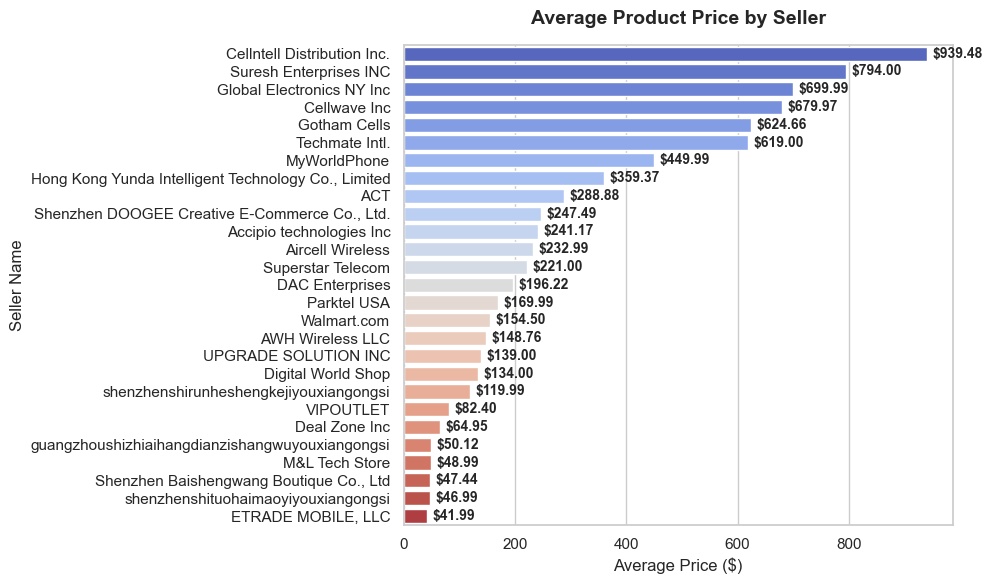

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

seller_price = df_final_merged.groupby('seller_name')['price($)'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))


ax = sns.barplot(x='price($)',y='seller_name', data=seller_price,hue='seller_name',palette='coolwarm',legend=False)

plt.title('Average Product Price by Seller', fontsize=14, pad=15, weight='bold')
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel('Seller Name', fontsize=12)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 10,p.get_y() + p.get_height() / 2,  f'${width:,.2f}', va='center', fontsize=10, weight='semibold')
plt.tight_layout()
plt.show()

In [44]:
df_final_merged.isna().sum()

SKU_id                 0
product_name           0
product_category       0
seller_name            0
seller_id              0
price($)               0
availability_status    0
average_rating         0
number_of_reviews      0
product_link           0
item_name              0
review_category        0
review_rating          0
review_title           0
review_text            0
review_date            0
recommended            0
positive_feedback      0
negative_feedback      0
reviewer_name          0
review_language        0
fulfilled_by           0
review_source          0
price_tier             0
dtype: int64

In [45]:
df_final_merged.dtypes

SKU_id                    int64
product_name             object
product_category         object
seller_name              object
seller_id                object
price($)                float64
availability_status      object
average_rating          float64
number_of_reviews         int64
product_link             object
item_name                object
review_category          object
review_rating           float64
review_title             object
review_text              object
review_date              object
recommended              object
positive_feedback       float64
negative_feedback       float64
reviewer_name            object
review_language          object
fulfilled_by             object
review_source            object
price_tier             category
dtype: object

In [46]:
product_distribution=df_final_merged.groupby('price_tier')['SKU_id'].count().reset_index(name='product_count')

C:\Users\91831\AppData\Local\Temp\ipykernel_8576\106994246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_distribution=df_final_merged.groupby('price_tier')['SKU_id'].count().reset_index(name='product_count')


### Product distribution across different price segment

In [47]:
print(product_distribution)

  price_tier  product_count
0     Budget            462
1  Mid-Range            431
2    Premium            420


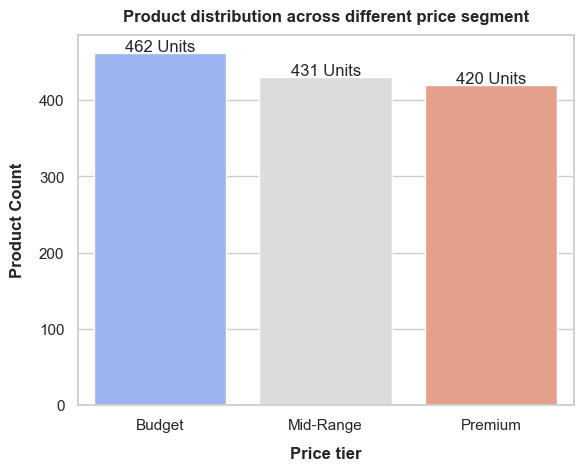

In [48]:
ax=sns.barplot(data=product_distribution,x='price_tier',y='product_count' ,hue='price_tier', palette='coolwarm')
plt.xlabel('Price tier' , weight = 'bold' , labelpad=10)
plt.ylabel('Product Count' , weight='bold' , labelpad=10)
plt.title("Product distribution across different price segment" , weight='bold' , pad='10')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2, height + 2,f'{height:.0f} Units',ha='center')

plt.show()

In [49]:
# pearson correlation between price and rating (range -1 to +1 )
price_rating_corr = df_final_merged[['price($)', 'review_rating']].corr()
print(f'correlation coefficient (price vs rating) :{price_rating_corr.iloc[1,0]:.2f}')

correlation coefficient (price vs rating) :0.24


In [50]:
# Top 5 product categories with the worst sentiment decline
df_final_merged['rating_gap'] = df_final_merged['review_rating'] - df_final_merged['average_rating']
worst_categories = df_final_merged.groupby('review_category')['rating_gap'].mean().sort_values(ascending=True).reset_index()


In [51]:
print(worst_categories)

                       review_category  rating_gap
0                      All Cell Phones   -2.700000
1                       5G AT&T Phones   -1.800000
2                   Refurbished Phones   -1.200000
3         Straight Talk Phones & Plans   -0.850000
4               Prepaid Android phones   -0.726626
5                               iPhone   -0.700000
6                  All Unlocked Phones   -0.400000
7                   5G Unlocked Phones   -0.382963
8                    5G Prepaid Phones   -0.379375
9                 Straight Talk iPhone   -0.375000
10   All Samsung Galaxy Prepaid Phones   -0.364706
11                     Prepaid iPhones   -0.193750
12  All Samsung Galaxy Unlocked Phones   -0.035802
13                      Android Phones    0.000000


### Plot for product with worst sentiment rating

In [52]:
top_5_decline=worst_categories.head(5)

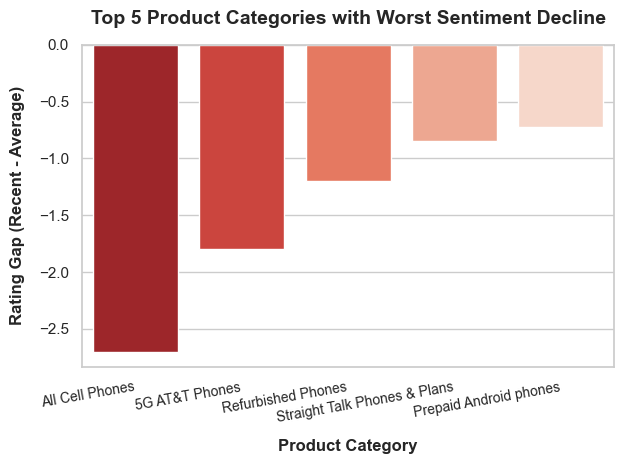

In [53]:
ax = sns.barplot( data=top_5_decline,
    x='review_category',
    y='rating_gap',
    hue='review_category',
    palette='Reds_r',  
    legend=False
)

plt.title('Top 5 Product Categories with Worst Sentiment Decline', fontsize=14, pad=15, weight='bold')
plt.xlabel('Product Category', fontsize=12, weight='bold', labelpad=10)
plt.ylabel('Rating Gap (Recent - Average)', fontsize=12, weight='bold', labelpad=10)

plt.xticks(rotation=10, ha='right', fontsize=10)




plt.tight_layout()
plt.show()

In [54]:
# Compare helpfulness metrics across ratings
helpfulness = df_final_merged.groupby('review_rating')['positive_feedback'].mean()
print(helpfulness)

review_rating
1.0    0.723906
2.0    0.169492
3.0    0.280374
4.0    0.236025
5.0    0.458636
Name: positive_feedback, dtype: float64


### Recommended product categories 

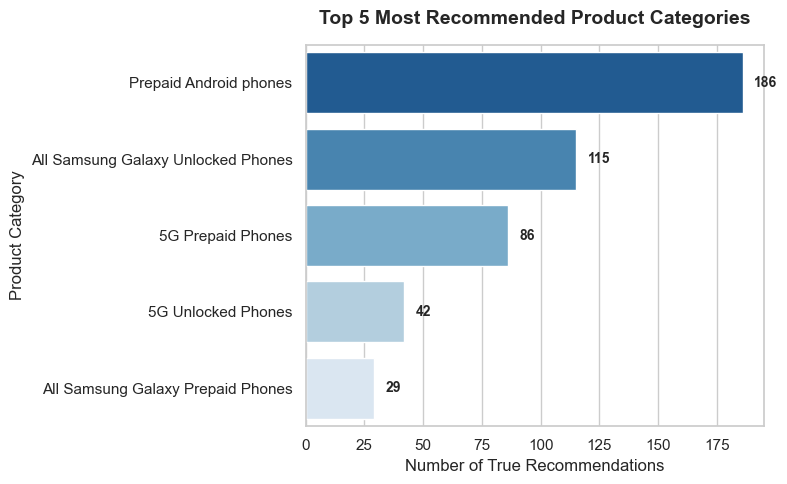

In [72]:

#Filter for true recommendation only
recommended_true_df = filtered_df[filtered_df['recommended'] == True]

#Searching for top 5 products with max recommendation
top_5_recommended = (
    recommended_true_df.groupby('review_category')['SKU_id'].count().sort_values(ascending=False)
    .head(5)
    .reset_index(name='recommendation_count')
)
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_5_recommended,
    x='recommendation_count',
    y='review_category',
    hue='review_category',
    palette='Blues_r',
    legend=False
)

plt.title('Top 5 Most Recommended Product Categories', fontsize=14, pad=15, weight='bold')
plt.xlabel('Number of True Recommendations', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 5, p.get_y() + p.get_height() / 2, f'{int(width)}', va='center', fontsize=10, 
                weight='semibold')

plt.tight_layout()
plt.show()

In [56]:
rec_percentages = pd.crosstab(
    filtered_df['review_category'], 
    filtered_df['recommended'], 
    normalize='index'
) * 100
print(rec_percentages)
category_loyalty = rec_percentages[True].sort_values(ascending=False).reset_index(name='Positive Recommendation')
negative_recom = rec_percentages[False].sort_values(ascending=False).reset_index(name='Negative Recommendation')
top_5_true_recommendation = category_loyalty.head(5)
top_5_false_recommendation = negative_recom.head(5)

recommended                             False       True  No recommendation
review_category                                                            
5G Prepaid Phones                   20.625000  53.750000          25.625000
5G Unlocked Phones                  16.296296  31.111111          52.592593
All Samsung Galaxy Prepaid Phones   16.176471  42.647059          41.176471
All Samsung Galaxy Unlocked Phones   6.995885  47.325103          45.679012
Prepaid Android phones              24.390244  37.804878          37.804878
Prepaid iPhones                      0.000000  31.250000          68.750000
Straight Talk Phones & Plans        14.000000  19.000000          67.000000
Straight Talk iPhone                15.000000  32.500000          52.500000
iPhone                              20.000000  35.000000          45.000000


In [57]:
rec_percentages = pd.crosstab(filtered_df['review_category'], filtered_df['recommended'], normalize='index') * 100
# calculating NPS , net recommendation score here (%TRUE-%FALSE recommendation)
rec_percentages['NPS'] = rec_percentages[True] - rec_percentages[False]
nps_sorted = rec_percentages.sort_values(by='NPS', ascending=False).reset_index()
print(nps_sorted[['review_category','NPS']])

recommended                     review_category        NPS
0            All Samsung Galaxy Unlocked Phones  40.329218
1                             5G Prepaid Phones  33.125000
2                               Prepaid iPhones  31.250000
3             All Samsung Galaxy Prepaid Phones  26.470588
4                          Straight Talk iPhone  17.500000
5                                        iPhone  15.000000
6                            5G Unlocked Phones  14.814815
7                        Prepaid Android phones  13.414634
8                  Straight Talk Phones & Plans   5.000000


### Product recommendation based on NPS Score

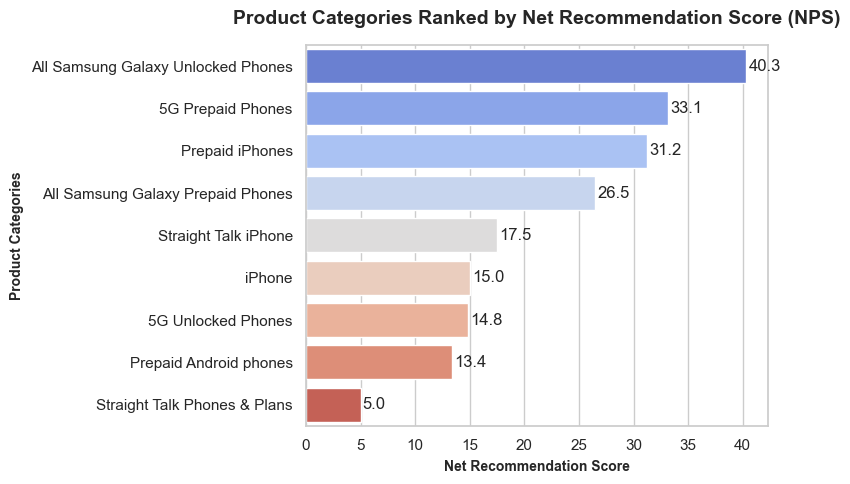

In [58]:
fig= plt.figure(figsize=(8,5))
sns.set_theme(style="whitegrid")
ax=sns.barplot(data=nps_sorted , x='NPS' , y='review_category' , hue='review_category' , palette='coolwarm')
plt.xlabel('Net Recommendation Score' , labelpad=5 , weight='bold' , fontsize=10)
plt.ylabel('Product Categories' , labelpad=5 , weight='bold' , fontsize=10)
plt.title('Product Categories Ranked by Net Recommendation Score (NPS)', fontsize=14, weight='bold', pad=15)
for p in ax.patches:
    width=p.get_width()
    ax.text(p.get_width()+0.2,p.get_y() + p.get_height()/2,    
        f'{p.get_width():.1f}',  va='center' )
plt.tight_layout()
plt.show()

### Quadrant plot distribution between prod_category and nps score

In [59]:
# Calculating Share of Voice (SoV) by prod category 
sov = (df_final_merged['review_category'].value_counts(normalize=True) * 100).reset_index()
sov.columns = ['review_category', 'Share of Voice (%)']

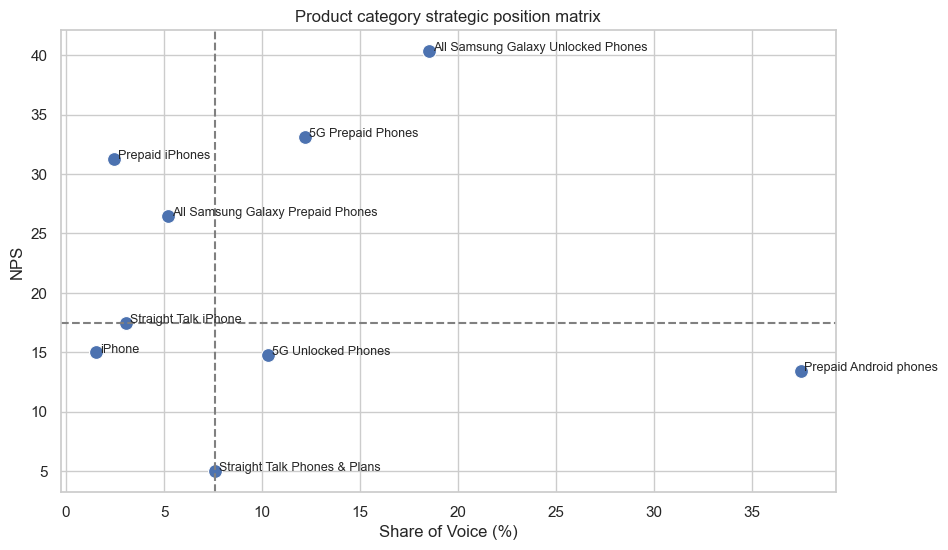

In [60]:
# merging the sov and quadrant-df on common key 'review_category' , by default , inner joining occurs
quadrant_df = nps_sorted.merge(sov, on='review_category')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=quadrant_df, x='Share of Voice (%)', y='NPS', s=100)

# Adding median lines to create the quadrant segement
plt.axhline(y=quadrant_df['NPS'].median(), color='gray', linestyle='--')
plt.axvline(x=quadrant_df['Share of Voice (%)'].median(), color='gray', linestyle='--')

for i, row in quadrant_df.iterrows():
    plt.text(row['Share of Voice (%)'] + 0.2, row['NPS'], row['review_category'], fontsize=9)

plt.title('Product category strategic position matrix')
plt.show()

##### Checking the relation between review word count and recommendation status especially (true / false ) one 

In [61]:
filtered_df

,SKU_id,product_name,product_category,seller_name,seller_id,price($),availability_status,average_rating,number_of_reviews,product_link,...,review_text,review_date,recommended,positive_feedback,negative_feedback,reviewer_name,review_language,fulfilled_by,review_source,price_tier
0,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...,...,this is definitely a 5 star and definitely wor...,1/21/2026,No recommendation,3.0,0.0,Uddu,English,Walmart,bazaarvoice,Budget
1,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...,...,The way your employees on the floor treat ppl ...,01-08-2026,No recommendation,2.0,0.0,WalmartCustomer,English,unknown,bazaarvoice,Budget
2,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...,...,Amazing phone for a great price! I have absolu...,05-05-2025,True,5.0,0.0,Collin,English,Walmart,bazaarvoice,Budget
3,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...,...,I needed a second line/phone for work. After ...,5/17/2025,No recommendation,7.0,2.0,Kk,English,Walmart,bazaarvoice,Budget
4,12835817248,"Straight Talk Samsung Galaxy A15, 64GB, 5G, Bl...",Cell Phones,Walmart.com,F55CDC31AB754BB68FE0B39041159D63,39.88,IN_STOCK,4.3,9203,/ip/Straight-Talk-Samsung-Galaxy-A15-64GB-5G-B...,...,I bought this phone on May 4th for $79. A coup...,5/22/2025,False,16.0,11.0,Craig,English,Walmart,bazaarvoice,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308,5035422406,Clearance！Smart Appliances 5.2 Inch HD Screen ...,Cell Phones,"Shenzhen Baishengwang Boutique Co., Ltd",ABC1A688E4EA4CF69B9FF40BC95C3BFF,47.44,IN_STOCK,2.4,119,/ip/Clearance-Smart-Appliances-5-2-Inch-HD-Scr...,...,without a Sim card it has no memory...,6/15/2025,No recommendation,0.0,0.0,Terri,English,Seller,bazaarvoice,Budget
1309,5035422406,Clearance！Smart Appliances 5.2 Inch HD Screen ...,Cell Phones,"Shenzhen Baishengwang Boutique Co., Ltd",ABC1A688E4EA4CF69B9FF40BC95C3BFF,47.44,IN_STOCK,2.4,119,/ip/Clearance-Smart-Appliances-5-2-Inch-HD-Scr...,...,i didn't get my package am very disappointed,6/17/2024,No recommendation,1.0,1.0,Gloria,English,unknown,bazaarvoice,Budget
1310,5035422406,Clearance！Smart Appliances 5.2 Inch HD Screen ...,Cell Phones,"Shenzhen Baishengwang Boutique Co., Ltd",ABC1A688E4EA4CF69B9FF40BC95C3BFF,47.44,IN_STOCK,2.4,119,/ip/Clearance-Smart-Appliances-5-2-Inch-HD-Scr...,...,It's too small and slow,3/26/2025,False,0.0,0.0,Erik,English,Seller,bazaarvoice,Budget
1311,5035422406,Clearance！Smart Appliances 5.2 Inch HD Screen ...,Cell Phones,"Shenzhen Baishengwang Boutique Co., Ltd",ABC1A688E4EA4CF69B9FF40BC95C3BFF,47.44,IN_STOCK,2.4,119,/ip/Clearance-Smart-Appliances-5-2-Inch-HD-Scr...,...,This phone sucks I'm returning the item and pi...,10/20/2023,No recommendation,0.0,0.0,Misty,English,unknown,bazaarvoice,Budget


### word count variability across different recommendation

In [65]:
filtered_df=filtered_df[filtered_df['recommended']!='No recommendation']

In [66]:
filtered_df['word_count']=filtered_df['review_text'].str.split().str.len()

C:\Users\91831\AppData\Local\Temp\ipykernel_8576\2361989223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['word_count']=filtered_df['review_text'].str.split().str.len()


<Axes: xlabel='recommended', ylabel='word_count'>

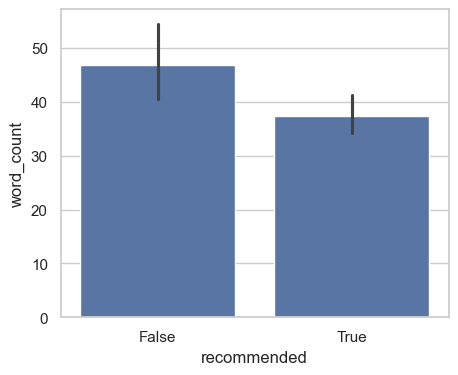

In [67]:
plt.figure(figsize=(5,4))
sns.barplot(data=filtered_df , x ='recommended' , y= 'word_count' )